In [1]:
import sys
sys.path.append('..') 
from model_architectures import *
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, OneCycleLR
from collections import Counter
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

Using device: cuda


In [2]:
# Enable GPU usage for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Create the ResNet18 model
NUM_CLASSES = 96  
GRAYSCALE = True  
mobile_net_model = MobileNetV2(num_classes=NUM_CLASSES, grayscale=True)
mobile_net_model.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
        (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
       

In [4]:
# Read the CSV file with specified data types
data = pd.read_csv("../archive/ascii_character_classification_sanrio_data_raw.csv", header=0)

label_counts = Counter(data.iloc[:, 0])
print(label_counts)

Counter({0.0: 2244300, 4.0: 160335, 40.0: 106923, 71.0: 54656, 80.0: 43406, 68.0: 32225, 75.0: 25995, 16.0: 20723, 59.0: 19169, 23.0: 18781, 65.0: 18637, 21.0: 10553, 66.0: 10161, 32.0: 9876, 20.0: 8248, 57.0: 4558, 82.0: 3799, 93.0: 3528, 91.0: 3199, 60.0: 1951, 25.0: 1877, 61.0: 1874, 73.0: 1517, 15.0: 1166, 56.0: 1095, 38.0: 1085, 88.0: 1081, 83.0: 974, 33.0: 898, 54.0: 825, 46.0: 820, 87.0: 807, 89.0: 676, 12.0: 637, 85.0: 615, 22.0: 607, 72.0: 589, 43.0: 501, 76.0: 487, 77.0: 473, 58.0: 464, 49.0: 443, 50.0: 362, 34.0: 355, 3.0: 292, 70.0: 282, 5.0: 273, 48.0: 244, 84.0: 222, 18.0: 215, 69.0: 159, 36.0: 129, 17.0: 101, 64.0: 101, 45.0: 97, 39.0: 93, 6.0: 84, 35.0: 83, 53.0: 82, 7.0: 80, 24.0: 78, 37.0: 59, 51.0: 57, 27.0: 54, 67.0: 51, 52.0: 41, 42.0: 35, 74.0: 33, 90.0: 25, 44.0: 19, 86.0: 18, 55.0: 15, 10.0: 15, 13.0: 10, 41.0: 10, 29.0: 9, 19.0: 4, 62.0: 4, 79.0: 2, 11.0: 1, 78.0: 1, 9.0: 1})


In [5]:
print(chr(12+32))

,


In [6]:
X = data.iloc[:, 1:].astype("float64")   # Features are all columns except the first one
y = data.iloc[:, 0].astype("float64")     # Labels are the first column

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
# Optionally, if you want to convert them back to pandas DataFrames:
train_data = pd.concat([y_train, X_train], axis=1)
test_data = pd.concat([y_test, X_test], axis=1)


93.0
5
char value:  $


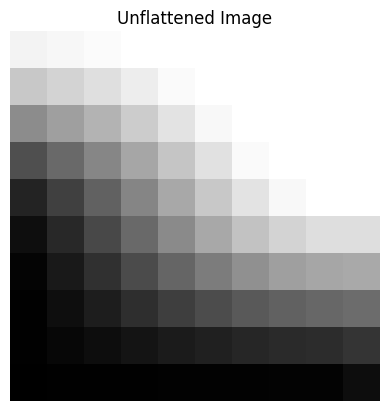

In [7]:
import matplotlib.pyplot as plt

# Find unique values in y_train
unique_values = y_train.unique()
unique_values = sorted(unique_values)

# Print unique values
print()

# Find the maximum value in y_train
max_value = y_train.max()

# Print the maximum value
print(max_value)

# Find the index where the third unique value occurs in y_train
value_to_find = unique_values[2]
idx = (y_train == value_to_find).idxmax()

# Print the index
print(idx)

# Convert the value to its corresponding character
char_value = chr(int(value_to_find)+32)
print("char value: ",char_value)

# Get the flattened array corresponding to the found index
flattened_array = X_train.iloc[idx].to_numpy()

# Reshape the array to its original dimensions
reshaped_array = flattened_array.reshape((10, 10))

# Display the image using Matplotlib
plt.imshow(reshaped_array, cmap='gray')  
plt.title('Unflattened Image')
plt.axis('off')  
plt.show()


In [8]:
train_labels = train_data.iloc[:, 0].values    
train_images = train_data.iloc[:, 1:].values 

test_labels = test_data.iloc[:, 0].values 
test_images = test_data.iloc[:, 1:].values 

# Convert to PyTorch tensors
train_images_tensor = torch.tensor(train_images, dtype=torch.float32)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)

test_images_tensor = torch.tensor(test_images, dtype=torch.float32)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

In [9]:
inc = 10
train_images_tensor = train_images_tensor.view(-1, 1, inc, inc)
test_images_tensor = test_images_tensor.view(-1, 1, inc, inc)
train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)

batch_size = 2048
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Move the data to the GPU
train_images_tensor, train_labels_tensor = train_images_tensor.to(device), train_labels_tensor.to(device)
test_images_tensor, test_labels_tensor = test_images_tensor.to(device), test_labels_tensor.to(device)

In [10]:


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobile_net_model.parameters(),  lr=1e-3)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)  # Adjust step_size and gamma as needed
# max_grad_norm = 1.0

# Compute Train Accuracy
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    for _, (features, targets) in enumerate(data_loader):
        features = features.to(device)
        targets = targets.to(device)
        class_probabilities = model(features)
        _, predicted_labels = torch.max(class_probabilities, 1)
        num_examples += targets.size(0)
        correct_pred += (predicted_labels == targets).sum().item()
    return correct_pred / num_examples * 100

# While training run nvidia-smi in the terminal to check gpu tasks 
train_accuracies = []
train_losses = []

# Training the model
num_epochs = 20
for epoch in range(num_epochs):
    total_correct = 0
    total_samples = 0
    epoch_losses = []

    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        # Move data to the GPU
        images, labels = images.to(device), labels.to(device)
        outputs = mobile_net_model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        
        # clip_grad_norm_(resnet18_model.parameters(), max_grad_norm)
        optimizer.step()

        train_losses.append(loss.item())

        # Calculate training accuracy
        current_lr = optimizer.param_groups[0]['lr']
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Learning Rate: {current_lr:.6f}')
    scheduler.step()
    
    training_accuracy = compute_accuracy(mobile_net_model, train_loader, device)
    train_accuracies.append(training_accuracy)

    # epoch_loss_avg = sum(epoch_losses) / len(epoch_losses)
    
    # train_losses.append(epoch_losses)
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Accuracy: {training_accuracy:.4f}')
    
print('Training finished.')

C:\Users\Sai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch [1/20], Step [100/1104], Loss: 0.1889, Learning Rate: 0.001000
Epoch [1/20], Step [200/1104], Loss: 0.1108, Learning Rate: 0.001000
Epoch [1/20], Step [300/1104], Loss: 0.1236, Learning Rate: 0.001000
Epoch [1/20], Step [400/1104], Loss: 0.1320, Learning Rate: 0.001000
Epoch [1/20], Step [500/1104], Loss: 0.1146, Learning Rate: 0.001000
Epoch [1/20], Step [600/1104], Loss: 0.0831, Learning Rate: 0.001000
Epoch [1/20], Step [700/1104], Loss: 0.0847, Learning Rate: 0.001000
Epoch [1/20], Step [800/1104], Loss: 0.0987, Learning Rate: 0.001000
Epoch [1/20], Step [900/1104], Loss: 0.0969, Learning Rate: 0.001000
Epoch [1/20], Step [1000/1104], Loss: 0.0652, Learning Rate: 0.001000
Epoch [1/20], Step [1100/1104], Loss: 0.0901, Learning Rate: 0.001000
Epoch [1/20], Training Accuracy: 97.3469
Epoch [2/20], Step [100/1104], Loss: 0.0681, Learning Rate: 0.001000
Epoch [2/20], Step [200/1104], Loss: 0.0726, Learning Rate: 0.001000
Epoch [2/20], Step [300/1104], Loss: 0.0657, Learning Rate: 

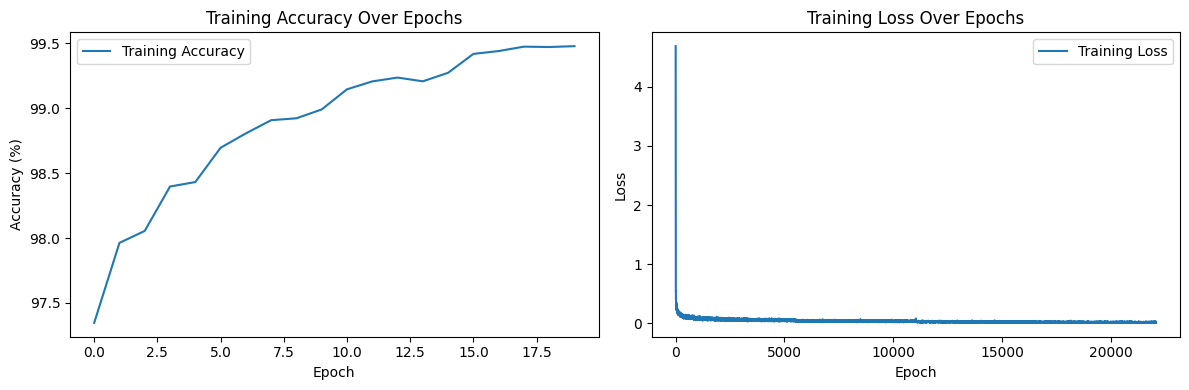

In [11]:
# Plotting training accuracies and losses
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
torch.save(mobile_net_model.state_dict(), f'../artifacts/mobilenetv2_ascii_classifier_sanrio_data_raw.pth')

In [13]:
# Reshape the images to [batch_size, 1, 10, 10]
test_images_tensor = test_images_tensor.view(-1, 1, 10, 10)

# Move the test data to the GPU
test_images_tensor, test_labels_tensor = test_images_tensor.to(device), test_labels_tensor.to(device)

# Create TensorDataset and DataLoader for the test data
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Evaluate the model on the test data
mobile_net_model.eval()  # Set the model to evaluation mode

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobile_net_model(images)
        probabilities = F.softmax(outputs, dim=1)
        
        _, predicted = torch.max(probabilities, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 99.04%
